# DSCI FINAL
## 組員
- 111590004
- 111590011
- 111590028
- 111590042

## 功能

主要是用來做分析用

# 載入資料

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False

# 讀取資料
bachelor_df = pd.read_csv("data/after_clean/大學資料_學士.csv", encoding="utf-8-sig")
master_df = pd.read_csv("data/after_clean/大學資料_碩士.csv", encoding="utf-8-sig")

salary_bachelor_df = pd.read_csv("data/after_clean/薪資統計_學士.csv", encoding="utf-8-sig")
salary_master_df = pd.read_csv("data/after_clean/薪資統計_碩士.csv", encoding="utf-8-sig")

lookup_df = pd.read_csv("data/before_clean/學門查詢.csv", encoding="utf-8-sig")

# 整理學門資料表

將不重要的學門資料排除

In [2]:
lookup_clean = lookup_df.copy()

for col, prefix in [
    ("領域代碼/名稱", "領域"),
    ("學門代碼/名稱", "學門"),
    ("學類代碼/名稱", "學類"),
    ("細學類代碼/名稱", "細學類"),
]:
    lookup_clean[f"{prefix}代碼"] = (
        lookup_clean[col]
        .astype(str)
        .str.extract(r"^(\d+)")[0]
    )

    lookup_clean[f"{prefix}名稱"] = (
        lookup_clean[col]
        .astype(str)
        .str.replace(r"^\d+\s*", "", regex=True)
    )

lookup_clean = lookup_clean[
    [
        "領域代碼", "領域名稱",
        "學門代碼", "學門名稱",
        "學類代碼", "學類名稱",
        "細學類代碼", "細學類名稱"
    ]
].drop_duplicates()

lookup_clean.head()

,領域代碼,領域名稱,學門代碼,學門名稱,學類代碼,學類名稱,細學類代碼,細學類名稱
0,01,教育領域,011,教育學門,0111,教育學學類,01111,綜合教育細學類
1,01,教育領域,011,教育學門,0111,教育學學類,01112,成人教育細學類
2,01,教育領域,011,教育學門,0111,教育學學類,01113,特殊教育細學類
3,01,教育領域,011,教育學門,0111,教育學學類,01114,教育行政細學類
4,01,教育領域,011,教育學門,0111,教育學學類,01115,課程與教學細學類


# 用科系代碼前五碼對應學門

讀取大學資料
將科系代碼過濾，比如 01111001 修正成 01111
讓資料可以與學門查詢的細學類代碼對應

In [3]:
def normalize_department_code(code):
    if pd.isna(code):
        return np.nan

    code = str(code).strip()

    if code.endswith(".0"):
        code = code[:-2]

    code = code.replace(" ", "")

    # 如果是純數字，且長度不足 8 碼，補回前導 0
    if code.isdigit() and len(code) < 8:
        code = code.zfill(8)

    return code

def prepare_university_data(df, degree_name):
    df = df.copy()

    df["學生數"] = pd.to_numeric(
        df["學生數"].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

    df["科系代碼_字串"] = df["科系代碼"].apply(normalize_department_code)

    # 科系代碼前五碼 = 細學類代碼
    df["細學類代碼"] = df["科系代碼_字串"].str[:5]

    df = df.merge(
        lookup_clean,
        on="細學類代碼",
        how="left"
    )

    df["學位"] = degree_name

    return df

bachelor_clean = prepare_university_data(bachelor_df, "學士")
master_clean = prepare_university_data(master_df, "碩士")

university_df = pd.concat(
    [bachelor_clean, master_clean],
    ignore_index=True
)

university_df.head()

,學校代碼,學校名稱,科系代碼,科系名稱,日間∕進修別,等級別,學生數,年份,科系代碼_字串,細學類代碼,領域代碼,領域名稱,學門代碼,學門名稱,學類代碼,學類名稱,細學類名稱,學位
0,1,國立政治大學,1111001,教育學系,D 日,B 學士,225.0,109,01111001,01111,01,教育領域,011,教育學門,0111,教育學學類,綜合教育細學類,學士
1,1,國立政治大學,2221020,歷史學系,D 日,B 學士,160.0,109,02221020,02221,02,藝術及人文領域,022,人文學門,0222,歷史及考古學學類,歷史細學類,學士
2,1,國立政治大學,2222031,民族學系,D 日,B 學士,178.0,109,02222031,02222,02,藝術及人文領域,022,人文學門,0222,歷史及考古學學類,人類學及民族學細學類,學士
3,1,國立政治大學,2231022,哲學系,D 日,B 學士,179.0,109,02231022,02231,02,藝術及人文領域,022,人文學門,0223,哲學學類,哲學細學類,學士
4,1,國立政治大學,2311009,英國語文學系,D 日,B 學士,292.0,109,02311009,02311,02,藝術及人文領域,023,語文學門,0231,外國語文學學類,外國語文細學類,學士


In [4]:
missing_lookup = university_df[university_df["學門名稱"].isna()]

print("無法對應學門的資料筆數：", len(missing_lookup))

missing_lookup[
    ["學位", "年份", "學校名稱", "科系代碼", "科系代碼_字串", "細學類代碼", "科系名稱"]
].drop_duplicates().head(30)

無法對應學門的資料筆數： 0


,學位,年份,學校名稱,科系代碼,科系代碼_字串,細學類代碼,科系名稱


# 統計 109～113 年各學門就讀人數

區分學士碩士

In [5]:
enroll_yearly = (
    university_df[
        university_df["學門名稱"].notna()
        & university_df["年份"].between(109, 113)
    ]
    .groupby(["學位", "年份", "學門名稱"], as_index=False)["學生數"]
    .sum()
    .rename(columns={"學門名稱": "學門"})
)

enroll_yearly.head()

,學位,年份,學門,學生數
0,學士,109,人文學門,9710.0
1,學士,109,其他學門,969.0
2,學士,109,商業及管理學門,82229.0
3,學士,109,安全服務學門,364.0
4,學士,109,工程及工程業學門,60067.0


# 人數近五年統計

In [6]:
enroll_summary = (
    enroll_yearly
    .groupby(["學位", "學門"], as_index=False)
    .agg(
        五年總就讀人數=("學生數", "sum"),
        五年平均就讀人數=("學生數", "mean"),
        人數年度數=("年份", "nunique")
    )
)

enroll_summary.head()

,學位,學門,五年總就讀人數,五年平均就讀人數,人數年度數
0,學士,人文學門,46438.0,9287.6,5
1,學士,其他學門,6476.0,1295.2,5
2,學士,商業及管理學門,389941.0,77988.2,5
3,學士,安全服務學門,1389.0,277.8,5
4,學士,工程及工程業學門,306015.0,61203.0,5


# 整理 109～113 畢業薪資

In [7]:
def prepare_salary_data(df):
    df = df.copy()

    df["薪資"] = pd.to_numeric(df["薪資"], errors="coerce")

    df["畢業年份"] = (
        df["畢業年"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .astype(int)
    )

    df["統計期_year"] = (
        df["統計期"]
        .astype(str)
        .str.extract(r"(\d+)年")[0]
        .astype(int)
    )

    df["統計期_month"] = (
        df["統計期"]
        .astype(str)
        .str.extract(r"年\s*(\d+)月")[0]
        .astype(int)
    )

    df = df[df["畢業年份"].between(109, 113)]

    latest_salary = (
        df.sort_values(["統計期_year", "統計期_month"])
        .groupby(["學位", "學門", "畢業年份"], as_index=False)
        .tail(1)
    )

    salary_summary = (
        latest_salary
        .groupby(["學位", "學門"], as_index=False)
        .agg(
            五年平均薪資=("薪資", "mean"),
            最高薪資=("薪資", "max"),
            最低薪資=("薪資", "min"),
            薪資畢業年數=("畢業年份", "nunique")
        )
    )

    return salary_summary

# 合併人數薪資

In [8]:
salary_summary = pd.concat(
    [
        prepare_salary_data(salary_bachelor_df),
        prepare_salary_data(salary_master_df)
    ],
    ignore_index=True
)

salary_summary.head()

,學位,學門,五年平均薪資,最高薪資,最低薪資,薪資畢業年數
0,學士,人文學門,38217.2,40421.0,35793.0,5
1,學士,其他學門,46909.2,57818.0,40446.0,5
2,學士,商業及管理學門,40304.2,42753.0,37392.0,5
3,學士,安全服務學門,38199.8,41208.0,35528.0,5
4,學士,工程及工程業學門,44809.0,48270.0,40264.0,5


In [9]:
analysis_df = enroll_summary.merge(
    salary_summary,
    on=["學位", "學門"],
    how="inner"
)

analysis_df.head()

,學位,學門,五年總就讀人數,五年平均就讀人數,人數年度數,五年平均薪資,最高薪資,最低薪資,薪資畢業年數
0,學士,人文學門,46438.0,9287.6,5,38217.2,40421.0,35793.0,5
1,學士,其他學門,6476.0,1295.2,5,46909.2,57818.0,40446.0,5
2,學士,商業及管理學門,389941.0,77988.2,5,40304.2,42753.0,37392.0,5
3,學士,安全服務學門,1389.0,277.8,5,38199.8,41208.0,35528.0,5
4,學士,工程及工程業學門,306015.0,61203.0,5,44809.0,48270.0,40264.0,5


# 算相關係數

In [10]:
def correlation_report(df, degree):
    target = df[
        df["學位"].eq(degree)
    ].dropna(subset=["五年平均就讀人數", "五年平均薪資"])

    pearson_result = pearsonr(
        target["五年平均就讀人數"],
        target["五年平均薪資"]
    )

    spearman_result = spearmanr(
        target["五年平均就讀人數"],
        target["五年平均薪資"]
    )

    print(f"===== {degree} =====")
    print(f"樣本數：{len(target)} 個學門")
    print(f"Pearson correlation：  {pearson_result.statistic:.3f}")
    print(f"Pearson p-value：      {pearson_result.pvalue:.4f}")
    print(f"Spearman correlation： {spearman_result.statistic:.3f}")
    print(f"Spearman p-value：     {spearman_result.pvalue:.4f}")

correlation_report(analysis_df, "學士")
correlation_report(analysis_df, "碩士")

===== 學士 =====
樣本數：27 個學門
Pearson correlation：  0.218
Pearson p-value：      0.2753
Spearman correlation： 0.189
Spearman p-value：     0.3444
===== 碩士 =====
樣本數：26 個學門
Pearson correlation：  0.572
Pearson p-value：      0.0023
Spearman correlation： 0.346
Spearman p-value：     0.0837


# 畫圖

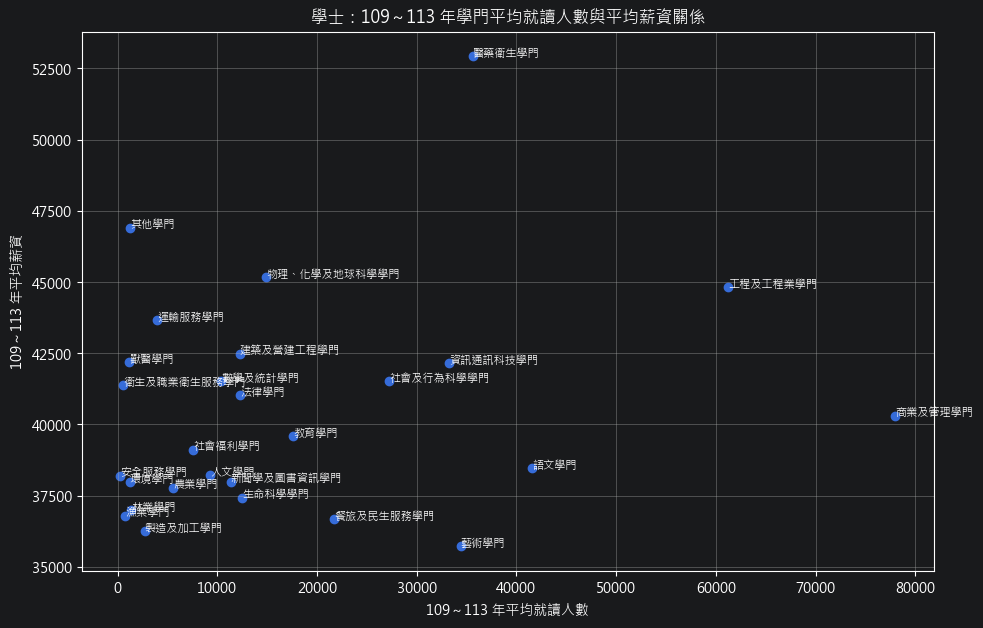

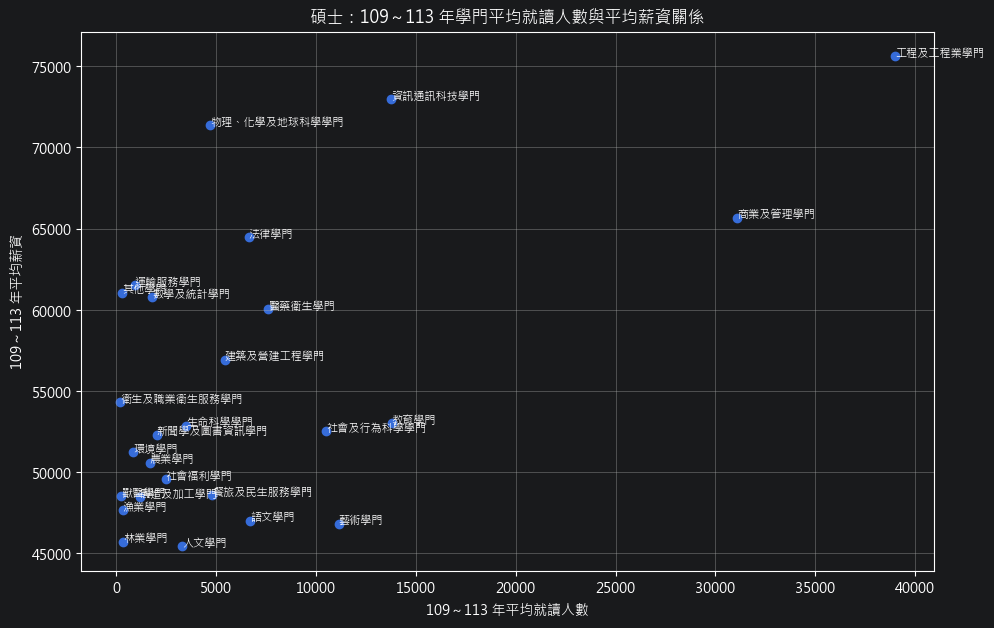

In [11]:
def plot_scatter(df, degree):
    target = df[df["學位"] == degree].copy()

    plt.figure(figsize=(11, 7))
    plt.scatter(
        target["五年平均就讀人數"],
        target["五年平均薪資"]
    )

    for _, row in target.iterrows():
        plt.text(
            row["五年平均就讀人數"],
            row["五年平均薪資"],
            row["學門"],
            fontsize=8
        )

    plt.title(f"{degree}：109～113 年學門平均就讀人數與平均薪資關係")
    plt.xlabel("109～113 年平均就讀人數")
    plt.ylabel("109～113 年平均薪資")
    plt.grid(True)
    plt.show()

plot_scatter(analysis_df, "學士")
plot_scatter(analysis_df, "碩士")

# 薪資前十名的圖

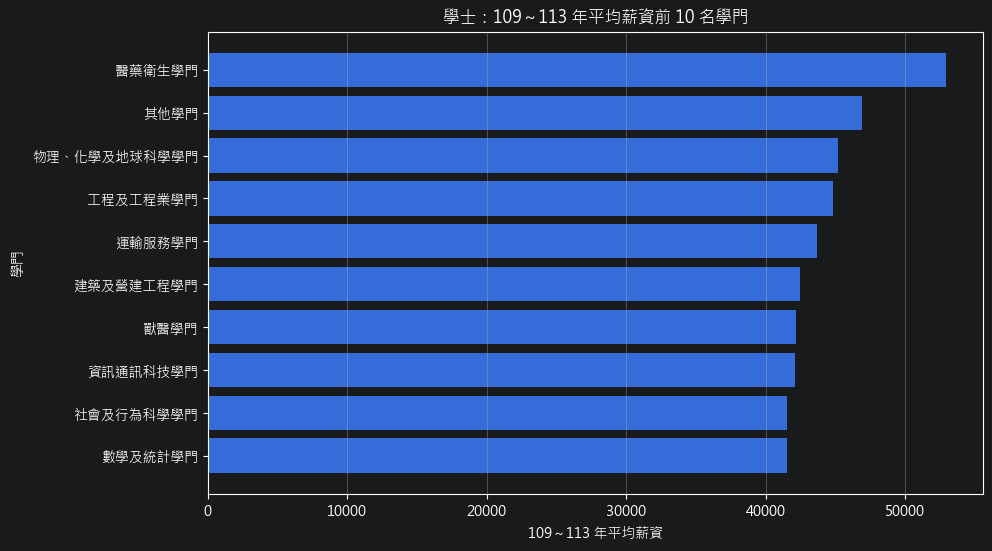

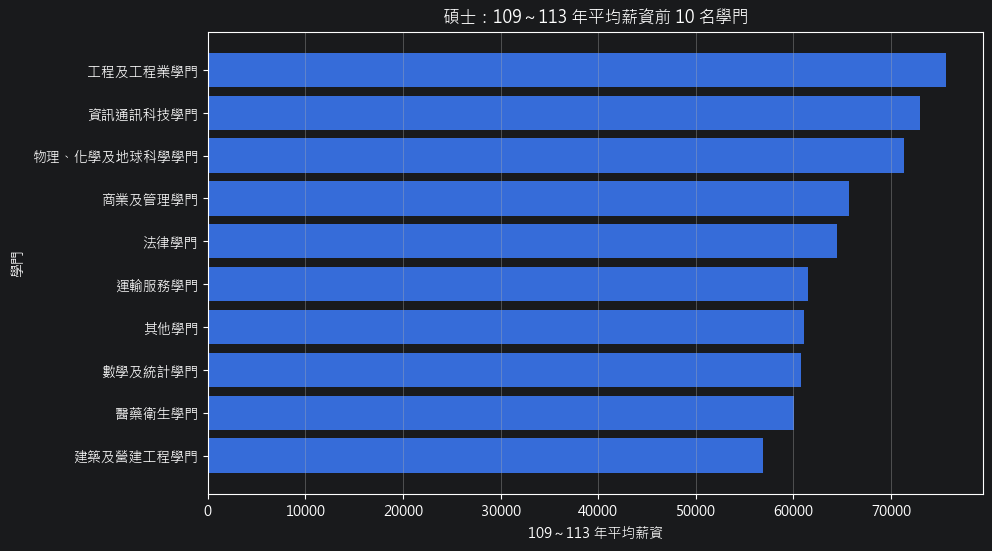

In [13]:
def plot_top_salary(df, degree, top_n=10):
    target = (
        df[df["學位"] == degree]
        .sort_values("五年平均薪資", ascending=False)
        .head(top_n)
        .sort_values("五年平均薪資")
    )

    plt.figure(figsize=(10, 6))
    plt.barh(target["學門"], target["五年平均薪資"])
    plt.title(f"{degree}：109～113 年平均薪資前 {top_n} 名學門")
    plt.xlabel("109～113 年平均薪資")
    plt.ylabel("學門")
    plt.grid(axis="x")
    plt.show()

plot_top_salary(analysis_df, "學士")
plot_top_salary(analysis_df, "碩士")

# 就讀人數前十名的圖


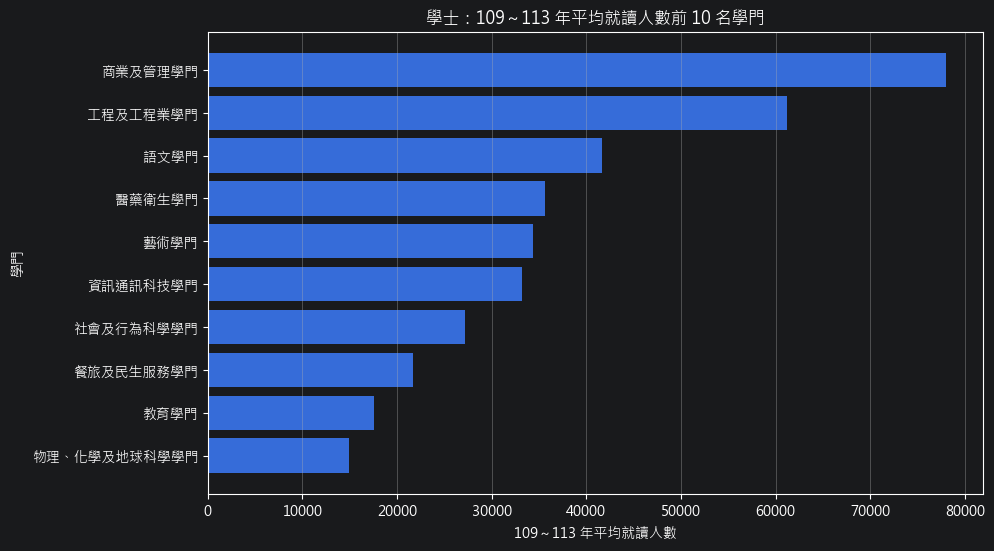

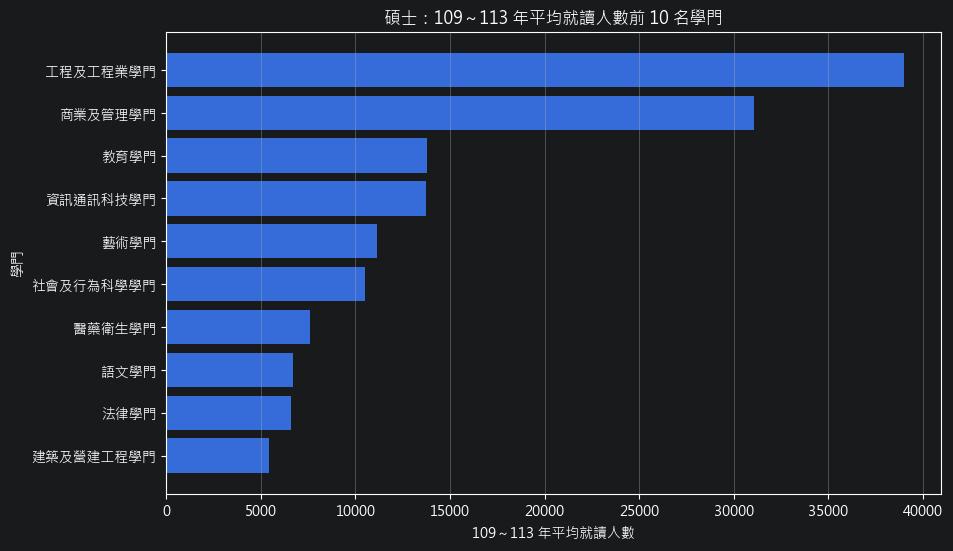

In [14]:
def plot_top_enrollment(df, degree, top_n=10):
    target = (
        df[df["學位"] == degree]
        .sort_values("五年平均就讀人數", ascending=False)
        .head(top_n)
        .sort_values("五年平均就讀人數")
    )

    plt.figure(figsize=(10, 6))
    plt.barh(target["學門"], target["五年平均就讀人數"])
    plt.title(f"{degree}：109～113 年平均就讀人數前 {top_n} 名學門")
    plt.xlabel("109～113 年平均就讀人數")
    plt.ylabel("學門")
    plt.grid(axis="x")
    plt.show()

plot_top_enrollment(analysis_df, "學士")
plot_top_enrollment(analysis_df, "碩士")

# 學碩士薪資差距


In [15]:
salary_compare = analysis_df.pivot(
    index="學門",
    columns="學位",
    values="五年平均薪資"
).reset_index()

salary_compare["碩士學士薪資差"] = salary_compare["碩士"] - salary_compare["學士"]

salary_compare.head()

學位,學門,學士,碩士,碩士學士薪資差
0,人文學門,38217.2,45447.2,7230.0
1,其他學門,46909.2,61047.6,14138.4
2,商業及管理學門,40304.2,65683.2,25379.0
3,安全服務學門,38199.8,NaN,NaN
4,工程及工程業學門,44809.0,75620.6,30811.6


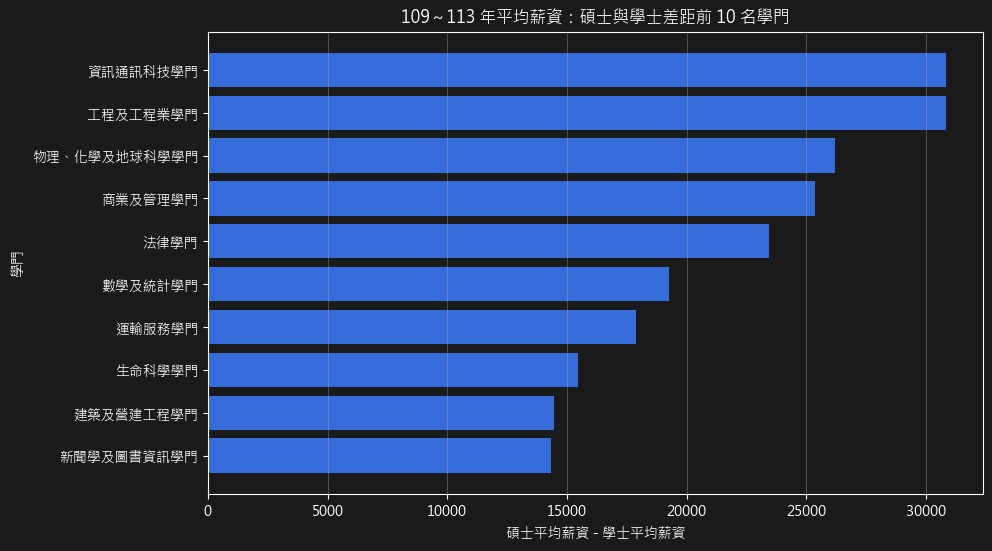

In [16]:
top_gap = (
    salary_compare
    .dropna()
    .sort_values("碩士學士薪資差", ascending=False)
    .head(10)
    .sort_values("碩士學士薪資差")
)

plt.figure(figsize=(10, 6))
plt.barh(top_gap["學門"], top_gap["碩士學士薪資差"])
plt.title("109～113 年平均薪資：碩士與學士差距前 10 名學門")
plt.xlabel("碩士平均薪資 - 學士平均薪資")
plt.ylabel("學門")
plt.grid(axis="x")
plt.show()